In [1]:
# ============================================================
# Standalone U-NO / UNO2D Quantitative Evaluation
#
# PT -> PA
#
# Metrics calculated on DENORMALIZED PA:
#
#   MSE      ↓
#   MAE      ↓
#   RMSE     ↓
#   Rel. L2  ↓
#   R²       ↑
#
# ============================================================

import os
import glob
import csv
import random
import time

import numpy as np
import h5py

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


# ============================================================
# 1. Configuration
# ============================================================

DATA_ROOT = r"Training dataset"


# ------------------------------------------------------------
# CHANGE THIS
#
# Example:
#
# RUN_DIR =
# r"uno2d_mat_dataset_results/run_20260827_105101"
# ------------------------------------------------------------

RUN_DIR = r"uno2d_mat_dataset_results/run_20260822_202604"


MODEL_PATH = os.path.join(
    RUN_DIR,
    "best_uno2d.pt"
)


NORM_PATH = os.path.join(
    RUN_DIR,
    "normalization_parameters.npz"
)


SUMMARY_PATH = os.path.join(
    RUN_DIR,
    "quantitative_metrics.txt"
)


CSV_PATH = os.path.join(
    RUN_DIR,
    "per_sample_metrics.csv"
)


# ============================================================
# 2. Dataset split
# ============================================================

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

SEED = 42


# ============================================================
# 3. Data size
# ============================================================

NT = 501
NX = 200


# ============================================================
# 4. UNO architecture parameters
#
# MUST be identical to training
# ============================================================

IN_CHANNELS = 1
OUT_CHANNELS = 1

BASE_WIDTH = 32


MODES_T_LEVEL1 = 64
MODES_X_LEVEL1 = 40

MODES_T_LEVEL2 = 32
MODES_X_LEVEL2 = 24

MODES_T_LEVEL3 = 16
MODES_X_LEVEL3 = 12

MODES_T_BOTTLENECK = 8
MODES_X_BOTTLENECK = 6


# ============================================================
# Evaluation batch size
# ============================================================

BATCH_SIZE = 4


# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 74)

print(
    "U-NO / UNO2D QUANTITATIVE EVALUATION"
)

print("=" * 74)


print(
    "\nUsing device:",
    DEVICE
)


# ============================================================
# 5. Check files
# ============================================================

if not os.path.exists(
    MODEL_PATH
):

    raise FileNotFoundError(

        f"\nCannot find UNO model:\n"
        f"{MODEL_PATH}\n\n"
        f"Please modify RUN_DIR."
    )


if not os.path.exists(
    NORM_PATH
):

    raise FileNotFoundError(

        f"\nCannot find normalization file:\n"
        f"{NORM_PATH}"
    )


print(
    "\nModel:"
)

print(
    MODEL_PATH
)


print(
    "\nNormalization:"
)

print(
    NORM_PATH
)


# ============================================================
# 6. Random seed
# ============================================================

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


# ============================================================
# 7. Find MAT files
# ============================================================

all_files = glob.glob(

    os.path.join(
        DATA_ROOT,
        "**",
        "*.mat"
    ),

    recursive=True
)


all_files = sorted(
    all_files
)


print(
    "\nTotal .mat samples found:",
    len(all_files)
)


if len(all_files) == 0:

    raise RuntimeError(

        f"No MAT files found under:\n"
        f"{DATA_ROOT}"
    )


# ============================================================
# 8. Reproduce original split exactly
#
# Original training:
#
# sorted(...)
# random.seed(42)
# random.shuffle(...)
# ============================================================

random.shuffle(
    all_files
)


n_total = len(
    all_files
)


n_train = int(
    n_total
    *
    TRAIN_RATIO
)


n_val = int(
    n_total
    *
    VAL_RATIO
)


train_files = all_files[
    :n_train
]


val_files = all_files[
    n_train:
    n_train + n_val
]


test_files = all_files[
    n_train + n_val:
]


print(
    "\nDataset split:"
)


print(
    "Train:",
    len(train_files)
)


print(
    "Val  :",
    len(val_files)
)


print(
    "Test :",
    len(test_files)
)


# ============================================================
# 9. Load training normalization parameters
# ============================================================

norm = np.load(
    NORM_PATH
)


pt_mean = float(
    norm["pt_mean"]
)


pt_std = float(
    norm["pt_std"]
)


pa_mean = float(
    norm["pa_mean"]
)


pa_std = float(
    norm["pa_std"]
)


print(
    "\nNormalization parameters:"
)


print(
    f"PT mean = {pt_mean:.8e}"
)


print(
    f"PT std  = {pt_std:.8e}"
)


print(
    f"PA mean = {pa_mean:.8e}"
)


print(
    f"PA std  = {pa_std:.8e}"
)


# ============================================================
# 10. Dataset
# ============================================================

class MatHeatAcousticDataset(
    Dataset
):

    def __init__(
        self,
        file_list,
        pt_mean,
        pt_std,
        pa_mean,
        pa_std
    ):

        self.file_list = file_list

        self.pt_mean = pt_mean
        self.pt_std = pt_std

        self.pa_mean = pa_mean
        self.pa_std = pa_std


    def __len__(
        self
    ):

        return len(
            self.file_list
        )


    def __getitem__(
        self,
        idx
    ):

        mat_path = self.file_list[
            idx
        ]


        with h5py.File(
            mat_path,
            "r"
        ) as f:


            PT = np.asarray(
                f["PT"],
                dtype=np.float32
            )


            PA = np.asarray(
                f["PA"],
                dtype=np.float32
            )


        # ====================================================
        # UNO training expects:
        #
        # [501, 200]
        # ====================================================

        if PT.shape != (
            NT,
            NX
        ):

            raise ValueError(

                f"Wrong PT shape in:\n"
                f"{mat_path}\n"
                f"{PT.shape}"
            )


        if PA.shape != (
            NT,
            NX
        ):

            raise ValueError(

                f"Wrong PA shape in:\n"
                f"{mat_path}\n"
                f"{PA.shape}"
            )


        # ====================================================
        # Normalize
        # ====================================================

        PT = (
            PT
            -
            self.pt_mean
        ) / self.pt_std


        PA = (
            PA
            -
            self.pa_mean
        ) / self.pa_std


        # ====================================================
        # [T,X]
        #
        # ->
        #
        # [C,T,X]
        # ====================================================

        PT = torch.tensor(
            PT,
            dtype=torch.float32
        ).unsqueeze(
            0
        )


        PA = torch.tensor(
            PA,
            dtype=torch.float32
        ).unsqueeze(
            0
        )


        return (
            PT,
            PA,
            mat_path
        )


# ============================================================
# 11. Test loader
# ============================================================

test_dataset = MatHeatAcousticDataset(

    test_files,

    pt_mean,
    pt_std,

    pa_mean,
    pa_std
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


print(
    "\nTest loader ready."
)


# ============================================================
# 12. Spectral Convolution
#
# IMPORTANT:
#
# UNO uses BOTH positive and negative temporal modes.
# ============================================================

class SpectralConv2d(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels,
        modes_t,
        modes_x
    ):

        super().__init__()


        self.in_channels = (
            in_channels
        )


        self.out_channels = (
            out_channels
        )


        self.modes_t = (
            modes_t
        )


        self.modes_x = (
            modes_x
        )


        scale = (
            1.0
            /
            (
                in_channels
                *
                out_channels
            )
        )


        # ====================================================
        # Positive temporal modes
        # ====================================================

        self.weights_pos = nn.Parameter(

            scale
            *
            torch.randn(

                in_channels,

                out_channels,

                modes_t,

                modes_x,

                dtype=torch.cfloat
            )
        )


        # ====================================================
        # Negative temporal modes
        # ====================================================

        self.weights_neg = nn.Parameter(

            scale
            *
            torch.randn(

                in_channels,

                out_channels,

                modes_t,

                modes_x,

                dtype=torch.cfloat
            )
        )


    def compl_mul2d(
        self,
        x,
        weights
    ):

        return torch.einsum(

            "bixy,ioxy->boxy",

            x,

            weights
        )


    def forward(
        self,
        x
    ):

        B, C, T, X = x.shape


        # ====================================================
        # FFT
        # ====================================================

        x_ft = torch.fft.rfftn(

            x,

            dim=(-2, -1)
        )


        # ====================================================
        # Output Fourier tensor
        # ====================================================

        out_ft = torch.zeros(

            B,

            self.out_channels,

            T,

            X // 2 + 1,

            dtype=torch.cfloat,

            device=x.device
        )


        # ====================================================
        # Safe modes
        # ====================================================

        mt = min(

            self.modes_t,

            T // 2
        )


        mx = min(

            self.modes_x,

            X // 2 + 1
        )


        # ====================================================
        # Positive temporal frequencies
        # ====================================================

        out_ft[
            :,
            :,
            :mt,
            :mx
        ] = self.compl_mul2d(

            x_ft[
                :,
                :,
                :mt,
                :mx
            ],

            self.weights_pos[
                :,
                :,
                :mt,
                :mx
            ]
        )


        # ====================================================
        # Negative temporal frequencies
        # ====================================================

        out_ft[
            :,
            :,
            -mt:,
            :mx
        ] = self.compl_mul2d(

            x_ft[
                :,
                :,
                -mt:,
                :mx
            ],

            self.weights_neg[
                :,
                :,
                :mt,
                :mx
            ]
        )


        # ====================================================
        # Inverse FFT
        # ====================================================

        x = torch.fft.irfftn(

            out_ft,

            s=(
                T,
                X
            ),

            dim=(-2, -1)
        )


        return x


# ============================================================
# 13. Operator Block
#
# Spectral branch
#
# +
#
# Local 1x1 convolution
#
# +
#
# GroupNorm
# ============================================================

class OperatorBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels,
        modes_t,
        modes_x
    ):

        super().__init__()


        self.spectral = SpectralConv2d(

            in_channels,

            out_channels,

            modes_t,

            modes_x
        )


        self.local = nn.Conv2d(

            in_channels,

            out_channels,

            kernel_size=1
        )


        # ====================================================
        # GroupNorm setup
        # ====================================================

        groups = min(
            8,
            out_channels
        )


        while (

            out_channels
            %
            groups
            !=
            0

            and

            groups
            >
            1
        ):

            groups -= 1


        self.norm = nn.GroupNorm(

            groups,

            out_channels
        )


    def forward(
        self,
        x
    ):


        x1 = self.spectral(
            x
        )


        x2 = self.local(
            x
        )


        x = (
            x1
            +
            x2
        )


        x = self.norm(
            x
        )


        x = F.gelu(
            x
        )


        return x


# ============================================================
# 14. Down Operator Block
# ============================================================

class DownOperatorBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels,
        modes_t,
        modes_x
    ):

        super().__init__()


        self.operator = OperatorBlock(

            in_channels,

            out_channels,

            modes_t,

            modes_x
        )


    def forward(
        self,
        x
    ):


        # ====================================================
        # Operator transform
        # ====================================================

        skip = self.operator(
            x
        )


        # ====================================================
        # Downsampling
        #
        # ceil_mode=True is important for T=501
        # ====================================================

        x = F.avg_pool2d(

            skip,

            kernel_size=2,

            stride=2,

            ceil_mode=True
        )


        return (
            x,
            skip
        )


# ============================================================
# 15. Up Operator Block
# ============================================================

class UpOperatorBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        modes_t,
        modes_x
    ):

        super().__init__()


        # ====================================================
        # Channel reduction
        # ====================================================

        self.reduce = nn.Conv2d(

            in_channels,

            out_channels,

            kernel_size=1
        )


        # ====================================================
        # Operator after concatenation
        # ====================================================

        self.operator = OperatorBlock(

            out_channels
            +
            skip_channels,

            out_channels,

            modes_t,

            modes_x
        )


    def forward(
        self,
        x,
        skip
    ):


        # ====================================================
        # Exact upsample to skip size
        # ====================================================

        x = F.interpolate(

            x,

            size=skip.shape[-2:],

            mode="bilinear",

            align_corners=False
        )


        x = self.reduce(
            x
        )


        # ====================================================
        # Skip connection
        # ====================================================

        x = torch.cat(

            [
                x,
                skip
            ],

            dim=1
        )


        # ====================================================
        # Neural operator mapping
        # ====================================================

        x = self.operator(
            x
        )


        return x


# ============================================================
# 16. U-shaped Neural Operator
# ============================================================

class UNO2D(
    nn.Module
):

    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_width=32
    ):

        super().__init__()


        # ====================================================
        # Channels
        # ====================================================

        c1 = base_width

        c2 = (
            base_width
            *
            2
        )

        c3 = (
            base_width
            *
            4
        )

        c4 = (
            base_width
            *
            8
        )


        # ====================================================
        # Input lifting
        #
        # PT + t-grid + x-grid
        # ====================================================

        self.lifting = nn.Conv2d(

            in_channels + 2,

            c1,

            kernel_size=1
        )


        # ====================================================
        # Encoder
        # ====================================================

        self.down1 = DownOperatorBlock(

            c1,

            c1,

            MODES_T_LEVEL1,

            MODES_X_LEVEL1
        )


        self.down2 = DownOperatorBlock(

            c1,

            c2,

            MODES_T_LEVEL2,

            MODES_X_LEVEL2
        )


        self.down3 = DownOperatorBlock(

            c2,

            c3,

            MODES_T_LEVEL3,

            MODES_X_LEVEL3
        )


        # ====================================================
        # Bottleneck
        # ====================================================

        self.bottleneck = OperatorBlock(

            c3,

            c4,

            MODES_T_BOTTLENECK,

            MODES_X_BOTTLENECK
        )


        # ====================================================
        # Decoder
        # ====================================================

        self.up3 = UpOperatorBlock(

            c4,

            c3,

            c3,

            MODES_T_LEVEL3,

            MODES_X_LEVEL3
        )


        self.up2 = UpOperatorBlock(

            c3,

            c2,

            c2,

            MODES_T_LEVEL2,

            MODES_X_LEVEL2
        )


        self.up1 = UpOperatorBlock(

            c2,

            c1,

            c1,

            MODES_T_LEVEL1,

            MODES_X_LEVEL1
        )


        # ====================================================
        # Local refinement
        # ====================================================

        self.refine = nn.Sequential(

            nn.Conv2d(

                c1,

                c1,

                kernel_size=3,

                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(

                c1,

                c1,

                kernel_size=3,

                padding=1
            ),

            nn.GELU()
        )


        # ====================================================
        # Output projection
        # ====================================================

        self.proj1 = nn.Conv2d(

            c1,

            128,

            kernel_size=1
        )


        self.proj2 = nn.Conv2d(

            128,

            out_channels,

            kernel_size=1
        )


    # ========================================================
    # Coordinate grid
    # ========================================================

    def get_grid(
        self,
        shape,
        device
    ):

        B, C, T, X = shape


        t = torch.linspace(

            0.0,

            1.0,

            T,

            device=device
        )


        x = torch.linspace(

            0.0,

            1.0,

            X,

            device=device
        )


        tt, xx = torch.meshgrid(

            t,

            x,

            indexing="ij"
        )


        grid = torch.stack(

            [
                tt,
                xx
            ],

            dim=0
        )


        grid = grid.unsqueeze(
            0
        )


        grid = grid.repeat(

            B,

            1,

            1,

            1
        )


        return grid


    # ========================================================
    # Forward
    # ========================================================

    def forward(
        self,
        x
    ):


        original_size = x.shape[
            -2:
        ]


        # ====================================================
        # Coordinates
        # ====================================================

        grid = self.get_grid(

            x.shape,

            x.device
        )


        x = torch.cat(

            [
                x,
                grid
            ],

            dim=1
        )


        # ====================================================
        # Lifting
        # ====================================================

        x = self.lifting(
            x
        )


        # ====================================================
        # Encoder
        # ====================================================

        x, skip1 = self.down1(
            x
        )


        x, skip2 = self.down2(
            x
        )


        x, skip3 = self.down3(
            x
        )


        # ====================================================
        # Bottleneck
        # ====================================================

        x = self.bottleneck(
            x
        )


        # ====================================================
        # Decoder
        # ====================================================

        x = self.up3(
            x,
            skip3
        )


        x = self.up2(
            x,
            skip2
        )


        x = self.up1(
            x,
            skip1
        )


        # ====================================================
        # Local refinement with residual
        # ====================================================

        residual = x


        x = self.refine(
            x
        )


        x = (
            x
            +
            residual
        )


        # ====================================================
        # Projection
        # ====================================================

        x = F.gelu(

            self.proj1(
                x
            )
        )


        x = self.proj2(
            x
        )


        # ====================================================
        # Safety
        # ====================================================

        if (
            x.shape[-2:]
            !=
            original_size
        ):


            x = F.interpolate(

                x,

                size=original_size,

                mode="bilinear",

                align_corners=False
            )


        return x


# ============================================================
# 17. Build UNO model
# ============================================================

uno_model = UNO2D(

    in_channels=IN_CHANNELS,

    out_channels=OUT_CHANNELS,

    base_width=BASE_WIDTH

).to(
    DEVICE
)


# ============================================================
# 18. Load trained UNO weights
# ============================================================

print(
    "\nLoading trained UNO2D..."
)


state_dict = torch.load(

    MODEL_PATH,

    map_location=DEVICE,

    weights_only=True
)


uno_model.load_state_dict(
    state_dict
)


uno_model.eval()


print(
    "UNO2D loaded successfully."
)


# ============================================================
# 19. Global accumulators
# ============================================================

global_sse = 0.0

global_sae = 0.0

global_target_sq = 0.0

global_target_sum = 0.0

global_n = 0


per_sample_results = []


# ============================================================
# 20. Test
# ============================================================

print(
    "\nEvaluating test set..."
)


sample_counter = 0


# ============================================================
# GPU timing
# ============================================================

if torch.cuda.is_available():

    torch.cuda.synchronize()


start_time = time.time()


with torch.no_grad():


    for (

        PT_norm,

        PA_norm,

        file_paths

    ) in tqdm(

        test_loader,

        desc="Testing",

        ncols=100

    ):


        # ====================================================
        # GPU
        # ====================================================

        PT_norm = PT_norm.to(

            DEVICE,

            non_blocking=True
        )


        # ====================================================
        # Prediction
        # ====================================================

        pred_norm = uno_model(
            PT_norm
        )


        # ====================================================
        # CPU
        # ====================================================

        pred_norm = (

            pred_norm
            .detach()
            .cpu()
            .numpy()
        )


        PA_norm_np = (
            PA_norm.numpy()
        )


        # ====================================================
        # DENORMALIZATION
        #
        # IMPORTANT:
        #
        # All quantitative metrics are calculated
        # on ORIGINAL PA values.
        # ====================================================

        pred_real = (

            pred_norm
            *
            pa_std
            +
            pa_mean
        )


        PA_real = (

            PA_norm_np
            *
            pa_std
            +
            pa_mean
        )


        current_batch_size = (
            pred_real.shape[0]
        )


        # ====================================================
        # Each sample
        # ====================================================

        for j in range(
            current_batch_size
        ):


            sample_counter += 1


            pred_j = (

                pred_real[j]
                .reshape(-1)
                .astype(
                    np.float64
                )
            )


            true_j = (

                PA_real[j]
                .reshape(-1)
                .astype(
                    np.float64
                )
            )


            error_j = (
                pred_j
                -
                true_j
            )


            # =================================================
            # MSE
            # =================================================

            mse_j = np.mean(
                error_j ** 2
            )


            # =================================================
            # MAE
            # =================================================

            mae_j = np.mean(

                np.abs(
                    error_j
                )
            )


            # =================================================
            # RMSE
            # =================================================

            rmse_j = np.sqrt(
                mse_j
            )


            # =================================================
            # Relative L2
            # =================================================

            rel_l2_j = (

                np.linalg.norm(
                    error_j
                )

                /

                (
                    np.linalg.norm(
                        true_j
                    )

                    +
                    1e-12
                )
            )


            # =================================================
            # R²
            # =================================================

            ss_res_j = np.sum(
                error_j ** 2
            )


            true_mean_j = np.mean(
                true_j
            )


            ss_tot_j = np.sum(

                (
                    true_j
                    -
                    true_mean_j
                )

                ** 2
            )


            r2_j = (

                1.0

                -

                ss_res_j

                /

                (
                    ss_tot_j
                    +
                    1e-12
                )
            )


            # =================================================
            # Save
            # =================================================

            per_sample_results.append(

                [
                    sample_counter,
                    file_paths[j],
                    mse_j,
                    mae_j,
                    rmse_j,
                    rel_l2_j,
                    r2_j
                ]
            )


            # =================================================
            # Global accumulation
            # =================================================

            global_sse += np.sum(
                error_j ** 2
            )


            global_sae += np.sum(

                np.abs(
                    error_j
                )
            )


            global_target_sq += np.sum(
                true_j ** 2
            )


            global_target_sum += np.sum(
                true_j
            )


            global_n += (
                true_j.size
            )


# ============================================================
# Make GPU timing correct
# ============================================================

if torch.cuda.is_available():

    torch.cuda.synchronize()


elapsed_time = (
    time.time()
    -
    start_time
)


# ============================================================
# 21. Global metrics
# ============================================================

# ------------------------------------------------------------
# MSE
# ------------------------------------------------------------

global_mse = (

    global_sse

    /

    global_n
)


# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------

global_mae = (

    global_sae

    /

    global_n
)


# ------------------------------------------------------------
# RMSE
# ------------------------------------------------------------

global_rmse = np.sqrt(
    global_mse
)


# ------------------------------------------------------------
# Relative L2
# ------------------------------------------------------------

global_rel_l2 = (

    np.sqrt(
        global_sse
    )

    /

    (
        np.sqrt(
            global_target_sq
        )

        +
        1e-12
    )
)


# ------------------------------------------------------------
# R²
#
# SST =
#
# sum(y²)
# -
# sum(y)²/N
# ------------------------------------------------------------

global_sst = (

    global_target_sq

    -

    (
        global_target_sum ** 2

        /

        global_n
    )
)


global_r2 = (

    1.0

    -

    global_sse

    /

    (
        global_sst

        +

        1e-12
    )
)


# ============================================================
# 22. Per-sample mean ± std
# ============================================================

metric_array = np.asarray(

    [
        row[2:]
        for row in per_sample_results
    ],

    dtype=np.float64
)


sample_mean = np.mean(
    metric_array,
    axis=0
)


sample_std = np.std(
    metric_array,
    axis=0
)


# ============================================================
# Timing
# ============================================================

time_per_sample = (

    elapsed_time

    /

    len(
        test_dataset
    )
)


# ============================================================
# 23. Print results
# ============================================================

print("\n")

print("=" * 74)

print(
    "U-NO / UNO2D FINAL QUANTITATIVE RESULTS"
)

print(
    "Metrics calculated on DENORMALIZED PA"
)

print("=" * 74)


print(
    f"MSE      : "
    f"{global_mse:.8e}"
)


print(
    f"MAE      : "
    f"{global_mae:.8e}"
)


print(
    f"RMSE     : "
    f"{global_rmse:.8e}"
)


print(
    f"Rel. L2  : "
    f"{global_rel_l2:.8e}"
)


print(
    f"R²       : "
    f"{global_r2:.8f}"
)


print("-" * 74)


print(
    "Per-sample mean ± std:"
)


print(
    f"MSE      : "
    f"{sample_mean[0]:.8e} "
    f"± "
    f"{sample_std[0]:.8e}"
)


print(
    f"MAE      : "
    f"{sample_mean[1]:.8e} "
    f"± "
    f"{sample_std[1]:.8e}"
)


print(
    f"RMSE     : "
    f"{sample_mean[2]:.8e} "
    f"± "
    f"{sample_std[2]:.8e}"
)


print(
    f"Rel. L2  : "
    f"{sample_mean[3]:.8e} "
    f"± "
    f"{sample_std[3]:.8e}"
)


print(
    f"R²       : "
    f"{sample_mean[4]:.8f} "
    f"± "
    f"{sample_std[4]:.8f}"
)


print("-" * 74)


print(
    f"Evaluation time : "
    f"{elapsed_time:.2f} s"
)


print(
    f"Time/sample     : "
    f"{time_per_sample:.4f} s"
)


print("=" * 74)


# ============================================================
# 24. Save per-sample CSV
# ============================================================

with open(

    CSV_PATH,

    "w",

    newline=""

) as f:


    writer = csv.writer(
        f
    )


    writer.writerow(

        [
            "sample",
            "file",
            "mse",
            "mae",
            "rmse",
            "relative_l2",
            "r2"
        ]
    )


    writer.writerows(
        per_sample_results
    )


# ============================================================
# 25. Save summary
# ============================================================

with open(

    SUMMARY_PATH,

    "w"

) as f:


    f.write(
        "UNO2D Quantitative Evaluation\n"
    )


    f.write(
        "Metrics calculated on "
        "DENORMALIZED PA\n\n"
    )


    f.write(
        "Global test-set metrics\n"
    )


    f.write(
        "=======================\n"
    )


    f.write(
        f"MSE      : "
        f"{global_mse:.8e}\n"
    )


    f.write(
        f"MAE      : "
        f"{global_mae:.8e}\n"
    )


    f.write(
        f"RMSE     : "
        f"{global_rmse:.8e}\n"
    )


    f.write(
        f"Rel. L2  : "
        f"{global_rel_l2:.8e}\n"
    )


    f.write(
        f"R2       : "
        f"{global_r2:.8f}\n"
    )


    f.write(
        "\nPer-sample mean +/- std\n"
    )


    f.write(
        "========================\n"
    )


    metric_names = [

        "MSE",

        "MAE",

        "RMSE",

        "Rel. L2",

        "R2"
    ]


    for (
        name,
        mean,
        std
    ) in zip(

        metric_names,

        sample_mean,

        sample_std

    ):


        f.write(

            f"{name:<8}: "

            f"{mean:.8e} "

            f"+/- "

            f"{std:.8e}\n"
        )


    f.write(
        "\nTiming\n"
    )


    f.write(
        "======\n"
    )


    f.write(

        f"Total evaluation time : "
        f"{elapsed_time:.4f} s\n"
    )


    f.write(

        f"Time per sample       : "
        f"{time_per_sample:.6f} s\n"
    )


# ============================================================
# 26. Finish
# ============================================================

print(
    "\nResults saved to:"
)


print(
    SUMMARY_PATH
)


print(
    CSV_PATH
)


print(
    "\nUNO2D quantitative evaluation complete."
)

U-NO / UNO2D QUANTITATIVE EVALUATION

Using device: cuda

Model:
uno2d_mat_dataset_results/run_20260822_202604/best_uno2d.pt

Normalization:
uno2d_mat_dataset_results/run_20260822_202604/normalization_parameters.npz

Total .mat samples found: 800

Dataset split:
Train: 640
Val  : 80
Test : 80

Normalization parameters:
PT mean = 3.13556727e+01
PT std  = 2.16473979e+01
PA mean = -2.10088660e+04
PA std  = 2.84782403e+05

Test loader ready.

Loading trained UNO2D...
UNO2D loaded successfully.

Evaluating test set...


Testing:   0%|                                                               | 0/20 [00:00<?, ?it/s]



U-NO / UNO2D FINAL QUANTITATIVE RESULTS
Metrics calculated on DENORMALIZED PA
MSE      : 1.02229607e+10
MAE      : 2.18390965e+04
RMSE     : 1.01108658e+05
Rel. L2  : 3.06984204e-01
R²       : 0.90500086
--------------------------------------------------------------------------
Per-sample mean ± std:
MSE      : 1.02229607e+10 ± 3.81944230e+10
MAE      : 2.18390965e+04 ± 4.60580990e+04
RMSE     : 4.45746635e+04 ± 9.07527415e+04
Rel. L2  : 3.03468062e-01 ± 1.69433319e-01
R²       : 0.87604400 ± 0.15508207
--------------------------------------------------------------------------
Evaluation time : 18.23 s
Time/sample     : 0.2279 s

Results saved to:
uno2d_mat_dataset_results/run_20260822_202604/quantitative_metrics.txt
uno2d_mat_dataset_results/run_20260822_202604/per_sample_metrics.csv

UNO2D quantitative evaluation complete.


PT shape: (501, 200)
PA ground-truth shape: (501, 200)
Network input shape: torch.Size([1, 1, 501, 200])
Predicted PA shape: (501, 200)


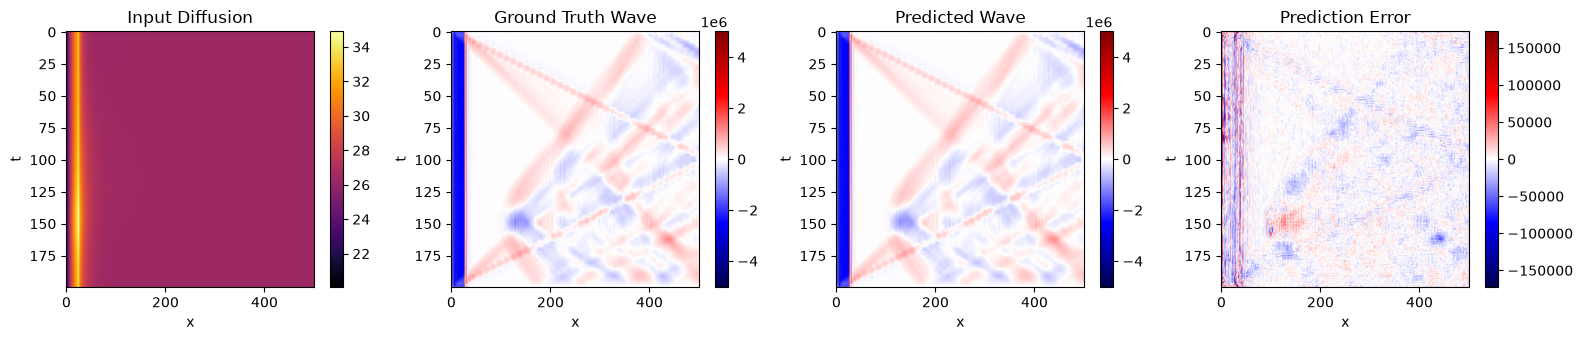

Figure saved to: uno2d_mat_dataset_results/run_20260822_202604/visualization_prediction/prediction_comparison.png


In [6]:
import os
import glob
import random
import numpy as np
import h5py
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# Visualization prediction
# ============================================================

PREDICT_FILE = os.path.join(
    DATA_ROOT,
    "1",
    "Irregular_3_PT_0.5.mat"
)

OUT_DIR_VIS = os.path.join(
    RUN_DIR,
    "visualization_prediction"
)

os.makedirs(
    OUT_DIR_VIS,
    exist_ok=True
)


# ============================================================
# Load prediction sample
# ============================================================

def load_prediction_sample(mat_path):

    assert os.path.isfile(mat_path), (
        f"Prediction file not found: {mat_path}"
    )

    with h5py.File(
        mat_path,
        "r"
    ) as f:

        PT = np.asarray(
            f["PT"],
            dtype=np.float32
        )

        if "PA" in f:

            PA = np.asarray(
                f["PA"],
                dtype=np.float32
            )

        else:

            PA = None


    assert PT.shape == (
        NT,
        NX
    ), (
        f"Wrong PT shape: {PT.shape}"
    )


    if PA is not None:

        assert PA.shape == (
            NT,
            NX
        ), (
            f"Wrong PA shape: {PA.shape}"
        )


    return PT, PA


# ============================================================
# Load data
# ============================================================

PT_real, PA_real = load_prediction_sample(
    PREDICT_FILE
)


print(
    "PT shape:",
    PT_real.shape
)


if PA_real is not None:

    print(
        "PA ground-truth shape:",
        PA_real.shape
    )

else:

    print(
        "No PA ground truth found in this file."
    )


# ============================================================
# Normalize input
# ============================================================

PT_norm = (

    PT_real
    -
    pt_mean

) / pt_std


PT_tensor = torch.tensor(

    PT_norm,

    dtype=torch.float32

).unsqueeze(
    0

).unsqueeze(
    0

).to(
    DEVICE
)


print(
    "Network input shape:",
    PT_tensor.shape
)


# ============================================================
# Prediction
# ============================================================

uno_model.eval()


with torch.no_grad():

    PA_pred_norm = uno_model(
        PT_tensor
    )


PA_pred_norm = (

    PA_pred_norm
    .cpu()
    .squeeze(0)
    .squeeze(0)
    .numpy()
)


# ============================================================
# Denormalize predicted PA
# ============================================================

PA_pred = (

    PA_pred_norm
    *
    pa_std
    +
    pa_mean
)


print(
    "Predicted PA shape:",
    PA_pred.shape
)


# ============================================================
# Visualization
# ============================================================

if PA_real is not None:


    error = (

        PA_pred
        -
        PA_real
    )


    # --------------------------------------------------------
    # Transpose for visualization
    #
    # [501, 200] -> [200, 501]
    # --------------------------------------------------------

    PT_plot = PT_real.T

    PA_real_plot = PA_real.T

    PA_pred_plot = PA_pred.T

    error_plot = error.T


    vmax = max(

        np.max(
            np.abs(
                PA_real_plot
            )
        ),

        np.max(
            np.abs(
                PA_pred_plot
            )
        )
    )


    evmax = np.max(
        np.abs(
            error_plot
        )
    )


    fig, axes = plt.subplots(

        1,

        4,

        figsize=(
            16,
            3.5
        )
    )


    # --------------------------------------------------------
    # Input PT
    # --------------------------------------------------------

    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    # --------------------------------------------------------
    # Ground truth PA
    # --------------------------------------------------------

    im1 = axes[1].imshow(

        PA_real_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Ground Truth Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    # --------------------------------------------------------
    # Predicted PA
    # --------------------------------------------------------

    im2 = axes[2].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[2].set_title(
        "Predicted Wave"
    )

    axes[2].set_xlabel(
        "x"
    )

    axes[2].set_ylabel(
        "t"
    )


    fig.colorbar(
        im2,
        ax=axes[2]
    )


    # --------------------------------------------------------
    # Error
    # --------------------------------------------------------

    im3 = axes[3].imshow(

        error_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-evmax,

        vmax=evmax
    )


    axes[3].set_title(
        "Prediction Error"
    )

    axes[3].set_xlabel(
        "x"
    )

    axes[3].set_ylabel(
        "t"
    )


    fig.colorbar(
        im3,
        ax=axes[3]
    )


    plt.tight_layout()


else:


    PT_plot = PT_real.T

    PA_pred_plot = PA_pred.T


    fig, axes = plt.subplots(

        1,

        2,

        figsize=(
            9,
            3.5
        )
    )


    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    vmax = np.max(
        np.abs(
            PA_pred_plot
        )
    )


    im1 = axes[1].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Predicted Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    plt.tight_layout()


# ============================================================
# Save figure
# ============================================================

plot_path = os.path.join(

    OUT_DIR_VIS,

    "prediction_comparison.png"
)


plt.savefig(

    plot_path,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "Figure saved to:",
    plot_path
)